# Configurações, Caminhos e Importações

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import glob
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from google.colab import drive

# Seeds para reprodutibilidade
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

drive.mount('/content/drive')

# --- CONFIGURAÇÃO DE CAMINHOS ---
dataset_path = '/content/drive/MyDrive/TCC/PKG - Osteosarcoma Tumor Assessment'
csv_path = '/content/drive/MyDrive/TCC/ML_Features_1144.csv'
save_model_path = '/content/drive/MyDrive/TCC/Modelos_Osteosarcoma'

os.makedirs(save_model_path, exist_ok=True)

# NOMES PARA O TESTE BRUTO DE 3 CLASSES
checkpoint_path = os.path.join(save_model_path, 'melhor_modelo_3classes_bruto_temp.keras')
final_model_name = os.path.join(save_model_path, 'EfficientNetB1_Osteosarcoma_3classes_bruto_Final.keras')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100

Mounted at /content/drive


# Mapeamento e Agrupamento das Classes

In [ ]:
print("Iniciando carregamento e mapeamento...")
df_original = pd.read_csv(csv_path)

# Criando uma cópia
df_copia = df_original.copy()

# ==============================================================================
# ALTERAÇÃO DO DATASET: Mesclando 'viable: non-viable' em 'Viable'
# ==============================================================================
df_copia['classification'] = df_copia['classification'].replace('viable: non-viable', 'Viable')

print("\nDistribuição das classes para o teste bruto de 3 classes:")
print(df_copia['classification'].value_counts())

# Mapeamento dos caminhos das imagens
all_image_paths = glob.glob(os.path.join(dataset_path, '**', '*.jpg'), recursive=True)
all_image_paths += glob.glob(os.path.join(dataset_path, '**', '*.JPG'), recursive=True)

normalized_path_lookup = {}
for p in all_image_paths:
    base = os.path.basename(p)
    name_no_ext = os.path.splitext(base)[0]
    norm_name = name_no_ext.lower().replace(" ", "").replace("-", "").replace("_", "")
    normalized_path_lookup[norm_name] = p

def get_full_path_robust(image_name):
    if pd.isna(image_name): return None
    norm_csv_name = str(image_name).lower().replace(" ", "").replace("-", "").replace("_", "")
    return normalized_path_lookup.get(norm_csv_name)

df_copia['full_path'] = df_copia['image.name'].apply(get_full_path_robust)
df_final = df_copia.dropna(subset=['full_path']).copy()

print(f"\nTotal de imagens mapeadas com sucesso: {len(df_final)} / 1144")

Iniciando carregamento e mapeamento...

Distribuição das classes para o teste bruto de 3 classes:
classification
Non-Tumor           536
Viable              345
Non-Viable-Tumor    263
Name: count, dtype: int64

Total de imagens mapeadas com sucesso: 1144 / 1144


# Divisão de Dados e Geradores (Sem pré-processamento)

In [ ]:
# 1. Divisão estratificada (70/15/15)
train_df, temp_df = train_test_split(
    df_final, train_size=0.7, stratify=df_final['classification'], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.5, stratify=temp_df['classification'], random_state=RANDOM_SEED
)

# 2. Gerador sem Data Augmentation e sem CLAHE
datagen = ImageDataGenerator()

train_gen = datagen.flow_from_dataframe(
    train_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    val_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

test_gen = datagen.flow_from_dataframe(
    test_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Found 800 validated image filenames belonging to 3 classes.
Found 172 validated image filenames belonging to 3 classes.
Found 172 validated image filenames belonging to 3 classes.


# Criação da Rede e Treinamento Bruto

In [ ]:
def build_model_osteo(num_classes=3):
    base_model = EfficientNetB1(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Congelado

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Instanciando para 3 classes
model = build_model_osteo(num_classes=3)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando Treinamento Inicial (Bruto - 3 Classes)...")
history = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=callbacks, verbose=1
)

# Salvar o modelo final bruto
model.save(final_model_name)
print(f"Treinamento bruto concluído! Modelo salvo em: {final_model_name}")

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Iniciando Treinamento Inicial (Bruto - 3 Classes)...
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.4456 - loss: 1.1235 
Epoch 1: val_loss improved from None to 0.57964, saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_3classes_bruto_temp.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_3classes_bruto_temp.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 459s 17s/step - accuracy: 0.5738 - loss: 0.8982 - val_accuracy: 0.8372 - val_loss: 0.5796
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.7946 - loss: 0.5645
Epoch 2: val_loss improved from 0.57964 to 0.43883, saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_3classes_bruto_temp.keras

Epoch 2: finished saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_3classes_bruto_temp.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 420ms/step - accurac

# Avaliação Final e Métricas (Sem CLAHE)

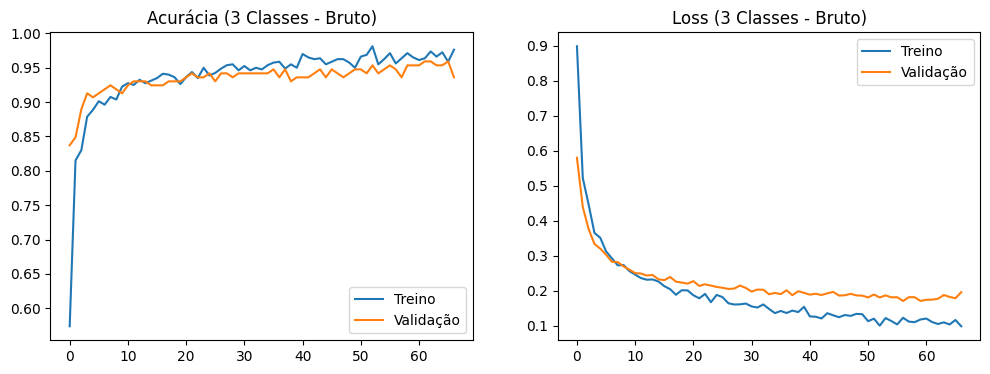

6/6 ━━━━━━━━━━━━━━━━━━━━ 66s 11s/step

--- RELATÓRIO DE CLASSIFICAÇÃO DETALHADO (3 CLASSES - BRUTO) ---
                  precision    recall  f1-score   support

       Non-Tumor     0.9625    0.9506    0.9565        81
Non-Viable-Tumor     0.8864    1.0000    0.9398        39
          Viable     0.9792    0.9038    0.9400        52

        accuracy                         0.9477       172
       macro avg     0.9427    0.9515    0.9454       172
    weighted avg     0.9503    0.9477    0.9477       172



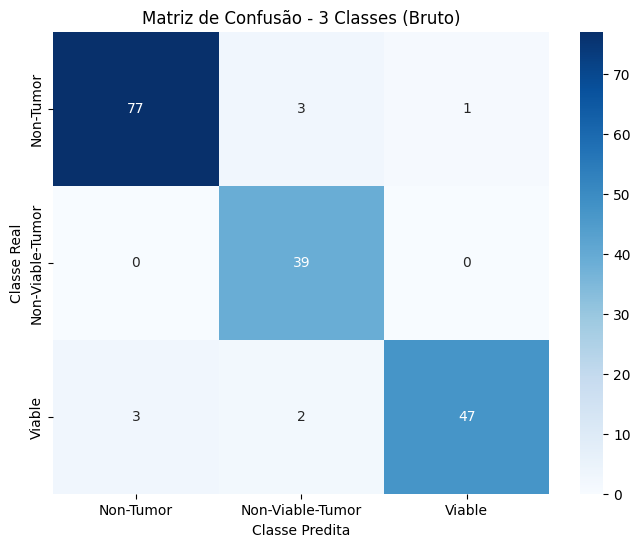

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Gráficos de Evolução do Treino
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia (3 Classes - Bruto)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss (3 Classes - Bruto)')
plt.legend()
plt.show()

# 2. Predição no conjunto de Teste
test_gen.reset()
Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# 3. Relatório de Classificação Detalhado
print("\n--- RELATÓRIO DE CLASSIFICAÇÃO DETALHADO (3 CLASSES - BRUTO) ---")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# 4. Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão - 3 Classes (Bruto)')
plt.show()